J-StockLab: Nikkei 225 Stock Prediction with Transformer

📁 Please upload 'total.csv' file...


Saving total.csv to total.csv

Loading data...
Data loaded: 4047 rows, 48 columns
Date range: 2014-10-16 00:00:00 ~ 2025-11-13 00:00:00

Handling missing values and filtering invalid data...
After cleaning: 4047 rows

Target stocks: 20 stocks
Economic features: 27 indicators
  - Japan FRED: 8 indicators
  - US FRED: 10 indicators
  - yfinance: 9 indicators

Scaling data...
Train/Test split: 3237 / 810 (80.0% / 20.0%)

Creating sequences...
Lookback window: 90 days
Forecast horizon: 7 days


/tmp/ipython-input-2174990466.py:78: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)
/tmp/ipython-input-2174990466.py:79: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='bfill', inplace=True)


Training data shape:
  X_stock: (3950, 90, 20) (samples, lookback, stocks)
  X_econ: (3950, 90, 27) (samples, lookback, indicators)
  y: (3950, 20) (samples, stocks)

Building Transformer Dual Input Model...

Model architecture:
  Stock Input: (90, 20)
  Economic Input: (90, 27)
  Transformer Layers: 4 layers each stream
  Multi-Head Attention: 8 heads
  Feed-Forward Dim: 256
  Output: 20 stocks (7-day forecast)


Model: "functional"

...

 Trainable params: 262,492 (1.00 MB)

 Non-trainable params: 0 (0.00 B)


Training model... (Epochs: 50, Batch size: 32, LR: 0.0001)
Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 68s 205ms/step - loss: 0.1384 - mae: 0.2540
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0078 - mae: 0.0648
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0040 - mae: 0.0463
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0030 - mae: 0.0402
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0024 - mae: 0.0361
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0022 - mae: 0.0345
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0020 - mae: 0.0327
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0018 - mae: 0.0312
Epoch 9/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0017 - mae: 0.0299
Epoch 10/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0016 - mae: 0.0292
Epoch 11/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0014 - mae: 0.0276
Epoch 12/50
124/124 ━━━━━━━━━━━━━━

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

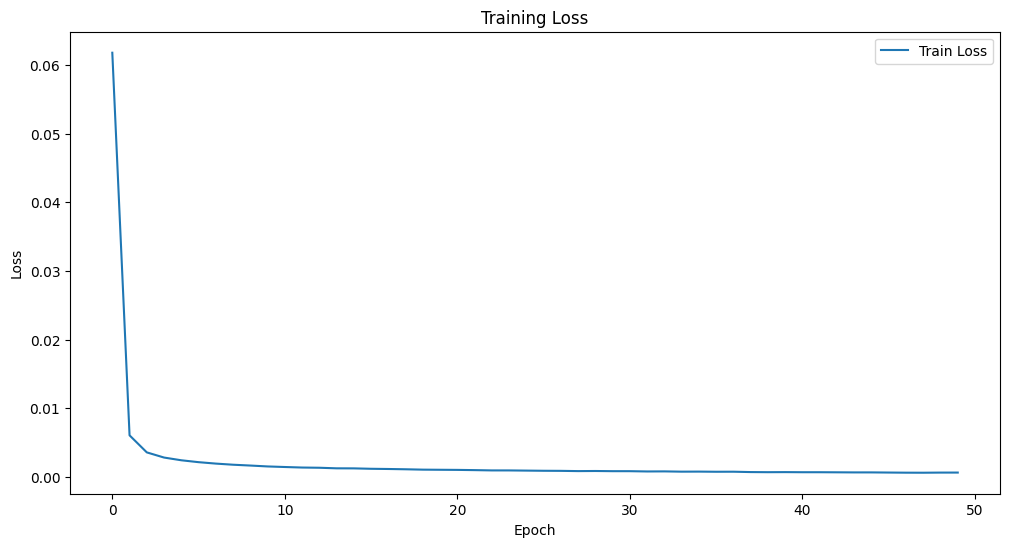


📊 Displaying sample stock predictions (5 stocks)...


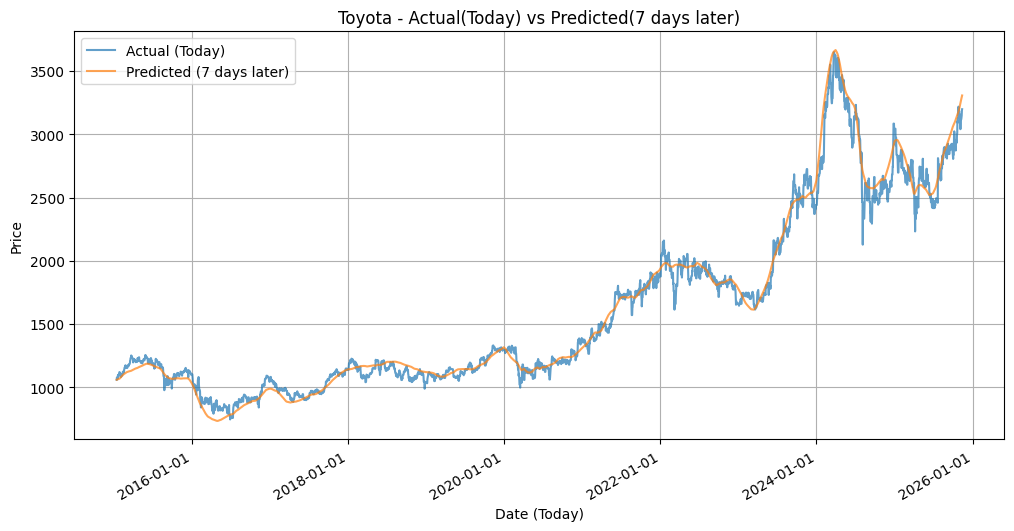

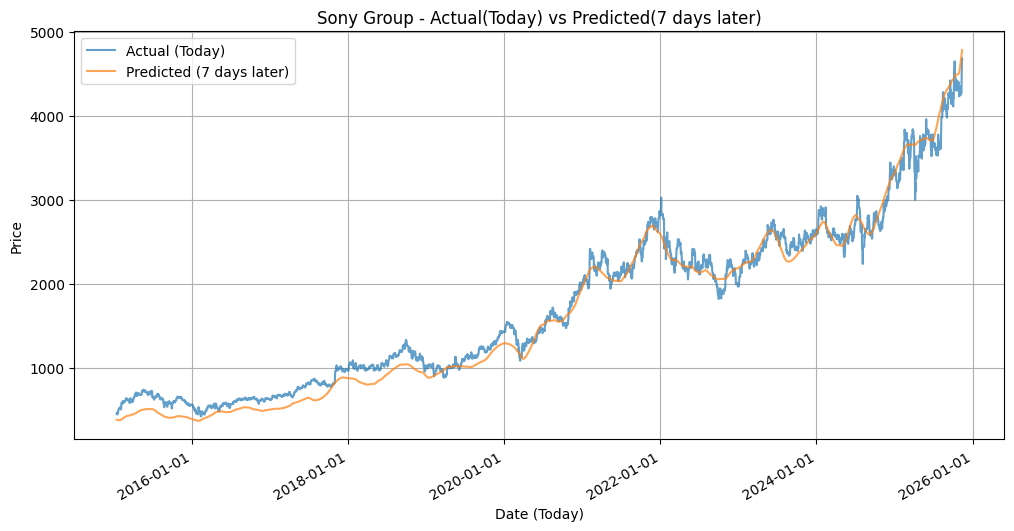

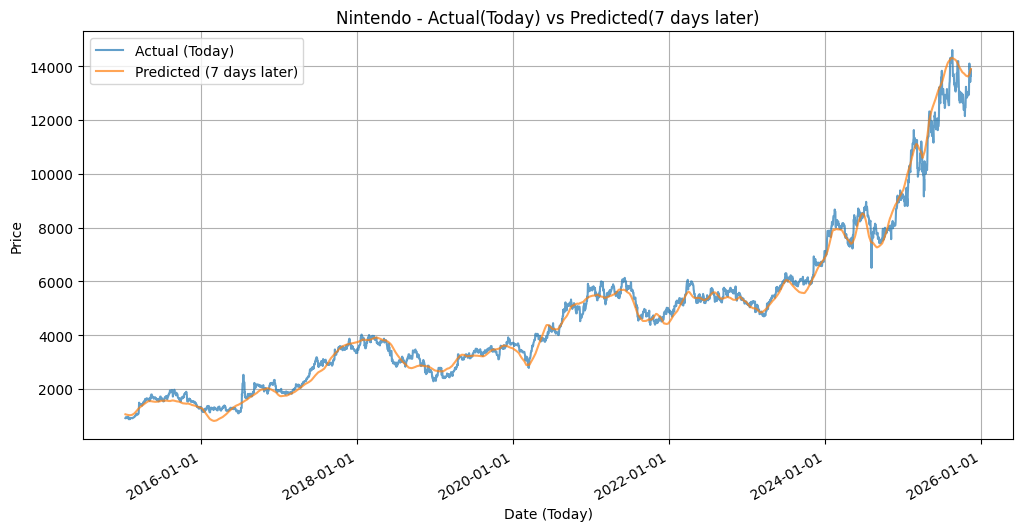

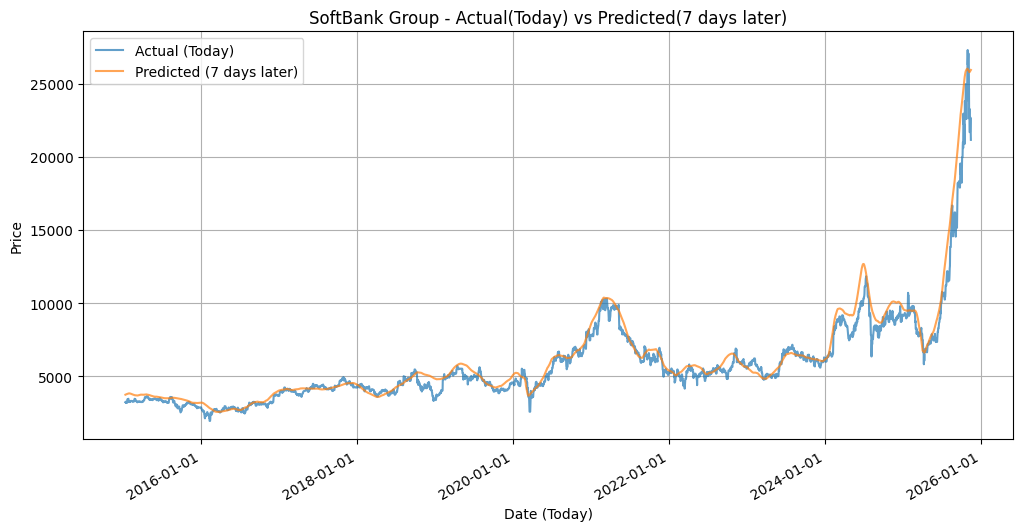

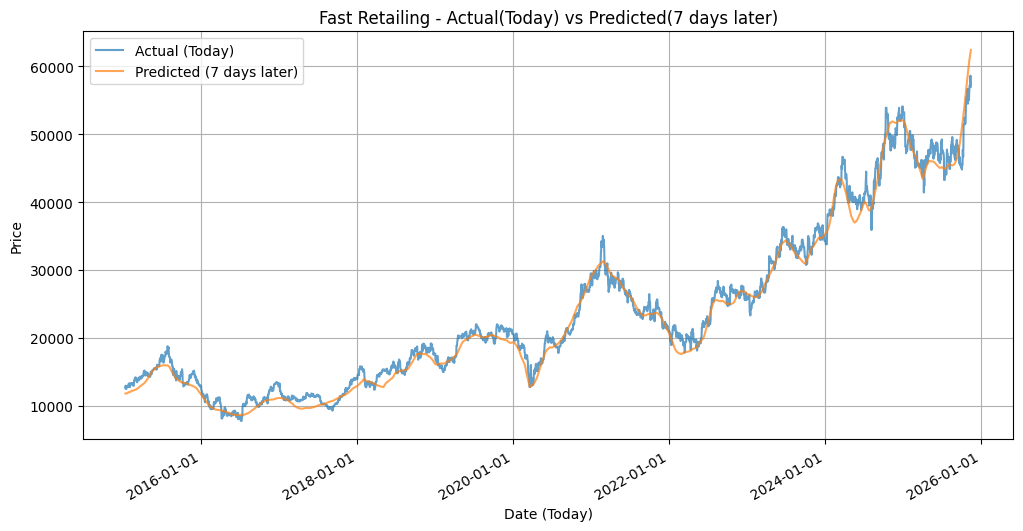


✅ All done! Check the downloaded 'predicted_stock.csv' file.


In [ ]:
"""
J-StockLab: 일본 주식 예측 - Transformer 모델 학습 및 예측

프로젝트: Nikkei 225 상위 20개 종목의 7일 후 주가 예측
모델: Transformer Dual Input Model
- Input 1: 주식 데이터 (20개 종목)
- Input 2: 경제 지표 (FRED 18개 + yfinance 9개)

작성자: 최정민, 김종수, 김용균
"""

# 파일 직접 업로드 방식 (Google Drive 불필요)
from google.colab import files
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, Add, GlobalAveragePooling1D
)
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Transformer Encoder 정의
def transformer_encoder(inputs, num_heads, ff_dim, dropout=0.1):
    attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=inputs.shape[-1])(inputs, inputs)
    attention_output = Dropout(dropout)(attention_output)
    attention_output = Add()([inputs, attention_output])
    attention_output = LayerNormalization(epsilon=1e-6)(attention_output)

    ffn = Dense(ff_dim, activation="relu")(attention_output)
    ffn = Dense(inputs.shape[-1])(ffn)
    ffn_output = Dropout(dropout)(ffn)
    ffn_output = Add()([attention_output, ffn_output])
    ffn_output = LayerNormalization(epsilon=1e-6)(ffn_output)

    return ffn_output

# Transformer 모델 정의
def build_transformer_with_two_inputs(stock_shape, econ_shape, num_heads, ff_dim, target_size):
    stock_inputs = Input(shape=stock_shape)
    stock_encoded = stock_inputs
    for _ in range(4):  # 4개의 Transformer Layer
        stock_encoded = transformer_encoder(stock_encoded, num_heads=num_heads, ff_dim=ff_dim)
    stock_encoded = Dense(64, activation="relu")(stock_encoded)

    econ_inputs = Input(shape=econ_shape)
    econ_encoded = econ_inputs
    for _ in range(4):  # 4개의 Transformer Layer
        econ_encoded = transformer_encoder(econ_encoded, num_heads=num_heads, ff_dim=ff_dim)
    econ_encoded = Dense(64, activation="relu")(econ_encoded)

    merged = Add()([stock_encoded, econ_encoded])
    merged = Dense(128, activation="relu")(merged)
    merged = Dropout(0.2)(merged)
    merged = GlobalAveragePooling1D()(merged)
    outputs = Dense(target_size)(merged)

    return Model(inputs=[stock_inputs, econ_inputs], outputs=outputs)

print("=" * 80)
print("J-StockLab: Nikkei 225 Stock Prediction with Transformer")
print("=" * 80)

print("\n📁 Please upload 'total.csv' file...")
uploaded = files.upload()

print("\nLoading data...")
file_path = list(uploaded.keys())[0]  # 업로드된 파일명 자동 인식
data = pd.read_csv(file_path, parse_dates=['날짜'])
data.sort_values(by='날짜', inplace=True)
print(f"Data loaded: {len(data)} rows, {len(data.columns)} columns")
print(f"Date range: {data['날짜'].min()} ~ {data['날짜'].max()}")

print("\nHandling missing values and filtering invalid data...")
data.fillna(method='ffill', inplace=True)
data.fillna(method='bfill', inplace=True)
data = data.apply(pd.to_numeric, errors='coerce')
data.dropna(inplace=True)
print(f"After cleaning: {len(data)} rows")

# 하이퍼파라미터
forecast_horizon = 7  # 예측 기간 (7일 후를 예측)
lookback = 90  # 과거 90일 데이터 사용
num_heads = 8  # Multi-Head Attention
ff_dim = 256  # Feed-Forward Dimension
epochs = 50
batch_size = 32
learning_rate = 0.0001

# Nikkei 225 상위 20개 종목 (시가총액 기준) - 영문명
target_columns = [
    'Toyota', 'SoftBank Group', 'Mitsubishi UFJ Financial', 'Sony Group',
    'Hitachi', 'Fast Retailing', 'SMFG', 'Nintendo',
    'Tokyo Electron', 'Advantest', 'Mitsubishi Heavy Ind', 'Mitsubishi Corp',
    'Keyence', 'Chugai Pharma', 'ITOCHU', 'Mizuho Financial',
    'NTT', 'Mitsui & Co', 'Recruit Holdings', 'Tokio Marine'
]

# 경제 지표: FRED 18개 + yfinance 9개 = 총 27개
economic_features = [
    # === 일본 경제 지표 (8개) ===
    '일본 실질 GDP', '일본 실업률', '일본 10년 국채 수익률',
    '일본 3개월 은행간 금리', '일본 총산업생산', '일본 무역수지',
    '일본 소비자 신뢰지수', '일본은행 총자산',

    # === 미국 경제 지표 (10개) ===
    '미국 10년 기대 인플레이션율', '미국 장단기 금리차', '미국 기준금리',
    '미국 2년 만기 국채 수익률', '미국 10년 만기 국채 수익률',
    '미시간대 소비자 심리지수', '미국 실업률', '미국 소비자 물가지수',
    '미국 GDP 성장률', '미국 금융스트레스지수',

    # === yfinance 시장 지표 (9개) ===
    '닛케이 225', '닛케이 300', 'TOPIX ETF',
    'S&P 500 지수', '나스닥 종합지수',
    'VIX 지수', '금 가격', '달러 인덱스', '엔/달러 환율'
]

print(f"\nTarget stocks: {len(target_columns)} stocks")
print(f"Economic features: {len(economic_features)} indicators")
print(f"  - Japan FRED: 8 indicators")
print(f"  - US FRED: 10 indicators")
print(f"  - yfinance: 9 indicators")

print("\nScaling data...")
train_size = int(len(data) * 0.8)
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]

data_scaled = data.copy()
stock_scaler = MinMaxScaler()
econ_scaler = MinMaxScaler()

data_scaled[target_columns] = stock_scaler.fit_transform(data[target_columns])
data_scaled[economic_features] = econ_scaler.fit_transform(data[economic_features])

print(f"Train/Test split: {train_size} / {len(data) - train_size} ({train_size/len(data)*100:.1f}% / {(1-train_size/len(data))*100:.1f}%)")

print(f"\nCreating sequences...")
print(f"Lookback window: {lookback} days")
print(f"Forecast horizon: {forecast_horizon} days")

# 훈련 데이터 생성
X_stock_train = []
X_econ_train = []
y_train = []

for i in range(lookback, len(data_scaled) - forecast_horizon):
    X_stock_seq = data_scaled[target_columns].iloc[i - lookback:i].to_numpy()
    X_econ_seq = data_scaled[economic_features].iloc[i - lookback:i].to_numpy()
    y_val = data_scaled[target_columns].iloc[i + forecast_horizon - 1].to_numpy()
    X_stock_train.append(X_stock_seq)
    X_econ_train.append(X_econ_seq)
    y_train.append(y_val)

X_stock_train = np.array(X_stock_train)
X_econ_train = np.array(X_econ_train)
y_train = np.array(y_train)

print(f"Training data shape:")
print(f"  X_stock: {X_stock_train.shape} (samples, lookback, stocks)")
print(f"  X_econ: {X_econ_train.shape} (samples, lookback, indicators)")
print(f"  y: {y_train.shape} (samples, stocks)")

# 전체 예측 데이터 생성: 마지막 날짜까지 포함하여 예측 (미래 실제값 없어도 예측)
X_stock_full = []
X_econ_full = []
for i in range(lookback, len(data_scaled)):  # 여기서 forecast_horizon 빼지 않음
    X_stock_seq = data_scaled[target_columns].iloc[i - lookback:i].to_numpy()
    X_econ_seq = data_scaled[economic_features].iloc[i - lookback:i].to_numpy()
    X_stock_full.append(X_stock_seq)
    X_econ_full.append(X_econ_seq)

X_stock_full = np.array(X_stock_full)
X_econ_full = np.array(X_econ_full)

print("\n" + "=" * 80)
print("Building Transformer Dual Input Model...")
print("=" * 80)
stock_shape = (lookback, len(target_columns))
econ_shape = (lookback, len(economic_features))

print(f"\nModel architecture:")
print(f"  Stock Input: {stock_shape}")
print(f"  Economic Input: {econ_shape}")
print(f"  Transformer Layers: 4 layers each stream")
print(f"  Multi-Head Attention: {num_heads} heads")
print(f"  Feed-Forward Dim: {ff_dim}")
print(f"  Output: {len(target_columns)} stocks (7-day forecast)")

model = build_transformer_with_two_inputs(stock_shape, econ_shape, num_heads=num_heads, ff_dim=ff_dim, target_size=len(target_columns))
model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse', metrics=['mae'])
model.summary()

print("\n" + "=" * 80)
print(f"Training model... (Epochs: {epochs}, Batch size: {batch_size}, LR: {learning_rate})")
print("=" * 80)
history = model.fit([X_stock_train, X_econ_train], y_train, epochs=epochs, batch_size=batch_size, verbose=1)

print("\n" + "=" * 80)
print("Performing full predictions...")
print("=" * 80)
predicted_prices = model.predict([X_stock_full, X_econ_full], verbose=1)
predicted_prices_actual = stock_scaler.inverse_transform(predicted_prices)
print(f"Predictions generated: {len(predicted_prices_actual)} samples")

pred_len = len(predicted_prices_actual)

# 오늘 날짜들 (마지막 날짜까지 포함)
today_dates = data['날짜'].iloc[lookback : lookback + pred_len].values

# 오늘 실제 주가 (오늘 날짜에 해당하는 실제값), 데이터 범위 넘어가면 NaN 처리
actual_data_end = min(lookback + pred_len, len(data))
actual_full = data[target_columns].iloc[lookback:actual_data_end].values

# 만약 actual_full 길이가 pred_len보다 짧다면 부족한 부분을 NaN으로 채움
if actual_full.shape[0] < pred_len:
    nan_padding = np.full((pred_len - actual_full.shape[0], len(target_columns)), np.nan)
    actual_full = np.vstack([actual_full, nan_padding])

result_data = pd.DataFrame({'날짜': today_dates})

for idx, col in enumerate(target_columns):
    result_data[f'{col}_Predicted'] = predicted_prices_actual[:, idx]
    result_data[f'{col}_Actual'] = actual_full[:, idx]

result_data['날짜'] = pd.to_datetime(result_data['날짜'], errors='coerce')
result_data['날짜'] = result_data['날짜'].dt.strftime('%Y-%m-%d')

output_file_path = 'predicted_stock.csv'
result_data.to_csv(output_file_path, index=False)
print(f"\n" + "=" * 80)
print(f"✅ Predicted stock prices saved to: {output_file_path}")
print(f"   - Total predictions: {len(result_data)} rows")
print(f"   - Columns: {len(result_data.columns)} (날짜 + {len(target_columns)*2} stock columns)")
print("=" * 80)

# 결과 파일 다운로드
print("\n📥 Downloading predicted_stock.csv...")
files.download(output_file_path)

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 대표 종목 5개만 그래프 출력 (전체 20개는 너무 많음)
sample_stocks = ['Toyota', 'Sony Group', 'Nintendo', 'SoftBank Group', 'Fast Retailing']
print(f"\n📊 Displaying sample stock predictions ({len(sample_stocks)} stocks)...")
for col in sample_stocks:
    plt.figure(figsize=(12, 6))
    plt.plot(pd.to_datetime(result_data['날짜']), result_data[f'{col}_Actual'], label='Actual (Today)', alpha=0.7)
    plt.plot(pd.to_datetime(result_data['날짜']), result_data[f'{col}_Predicted'], label='Predicted (7 days later)', alpha=0.7)
    plt.title(f'{col} - Actual(Today) vs Predicted(7 days later)')
    plt.xlabel('Date (Today)')
    plt.ylabel('Price')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid()
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.gcf().autofmt_xdate()
    plt.show()

print("\n✅ All done! Check the downloaded 'predicted_stock.csv' file.")


In [1]:
"""
J-StockLab: 일본 주식 예측 - 평가 리포트 및 매수/매도 추천

프로젝트: Nikkei 225 상위 20개 종목의 7일 후 주가 예측 평가
- 평가 지표: MAE, MSE, RMSE, MAPE, Accuracy
- 상승/하락 분석 및 매수/매도 추천
- 파일 직접 업로드 방식 (Google Drive 불필요)

작성자: 최정민, 김종수, 김용균
"""

# 파일 직접 업로드 방식 (Google Drive 불필요)
from google.colab import files
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

######################
# (1) Evaluation Function
######################
def evaluate_predictions(data, target_columns, forecast_horizon):
    """
    실제값과 예측값을 비교하여 다양한 평가 지표를 계산합니다.

    - MAE (Mean Absolute Error): 평균 절대 오차
      (낮을수록 좋음, 원본 데이터와 동일한 단위)
    - MSE (Mean Squared Error): 평균 제곱 오차
      (낮을수록 좋음)
    - RMSE (Root Mean Squared Error): MSE의 제곱근
      (낮을수록 좋음, MAE와 함께 자주 사용됨)
    - MAPE (Mean Absolute Percentage Error): 평균 절대 백분율 오차
      (낮을수록 좋음, 백분율로 표현)
    - Accuracy (%): 정확도 (100 - MAPE)
    """

    metrics = []

    for col in target_columns:
        predicted_col = f'{col}_Predicted'
        actual_col = f'{col}_Actual'

        # 컬럼 존재 여부 확인
        if predicted_col not in data.columns or actual_col not in data.columns:
            print(f"Skipping {col}: Columns not found in data")
            continue

        # 예측값 및 실제값 추출
        predicted = data[predicted_col]
        # 7일 후의 실제값과 비교하기 위해 shift 적용
        actual = data[actual_col].shift(-forecast_horizon)

        # 유효한 데이터만 사용 (NaN 제거)
        valid_idx = ~predicted.isna() & ~actual.isna()
        predicted = predicted[valid_idx]
        actual = actual[valid_idx]

        if len(predicted) == 0:
            print(f"Skipping {col}: No valid prediction/actual pairs.")
            continue

        # 평가 지표 계산
        mae = mean_absolute_error(actual, predicted)
        mse = mean_squared_error(actual, predicted)
        rmse = mse ** 0.5
        mape = (abs((actual - predicted) / actual).mean()) * 100
        accuracy = 100 - mape

        metrics.append({
            'Stock': col,
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'MAPE (%)': mape,
            'Accuracy (%)': accuracy
        })

    return pd.DataFrame(metrics)

###############################
# (2) Future Rise Analysis
###############################
def analyze_rise_predictions(data, target_columns):
    """
    가장 최근 데이터 기준으로 7일 후 상승/하락 예측 분석
    - 마지막 행의 실제 주가와 예측 주가를 비교
    - 상승 확률(%) 계산
    """

    last_row = data.iloc[-1]
    results = []

    for col in target_columns:
        last_actual_price = last_row.get(f'{col}_Actual', np.nan)
        predicted_future_price = last_row.get(f'{col}_Predicted', np.nan)

        # 상승/하락 및 상승 확률 계산
        if pd.notna(last_actual_price) and pd.notna(predicted_future_price):
            predicted_rise = predicted_future_price > last_actual_price
            rise_probability = ((predicted_future_price - last_actual_price) / last_actual_price) * 100
        else:
            predicted_rise = np.nan
            rise_probability = np.nan

        results.append({
            'Stock': col,
            'Last Actual Price': last_actual_price,
            'Predicted Future Price': predicted_future_price,
            'Predicted Rise': predicted_rise,
            'Rise Probability (%)': rise_probability
        })

    return pd.DataFrame(results)

#######################################
# (3) Buy/Sell Recommendation and Analysis
#######################################
def generate_recommendation(row):
    """
    매수/매도 추천 로직:
    - 상승 예측 & 상승률 > 0% => BUY
    - 상승률 > 2% => STRONG BUY
    - 그 외 => SELL
    """
    rise_prob = row.get('Rise Probability (%)', 0)
    predicted_rise = row.get('Predicted Rise', False)

    if pd.isna(rise_prob) or pd.isna(predicted_rise):
        return "No Data"

    if predicted_rise and rise_prob > 0:
        if rise_prob > 2:
            return "STRONG BUY"
        else:
            return "BUY"
    else:
        return "SELL"

def generate_analysis(row):
    """
    각 종목에 대한 간단한 분석 코멘트 생성
    """
    stock_name = row['Stock']
    rise_prob = row.get('Rise Probability (%)', 0)
    predicted_rise = row.get('Predicted Rise', False)

    if pd.isna(rise_prob) or pd.isna(predicted_rise):
        return f"{stock_name}: Not enough data"

    if predicted_rise:
        return f"{stock_name} is expected to rise by about {rise_prob:.2f}%. Consider buying or holding."
    else:
        return f"{stock_name} is expected to fall by about {-rise_prob:.2f}%. A cautious approach is recommended."

#######################
# (4) Main Code
#######################
print("=" * 80)
print("J-StockLab: Nikkei 225 Stock Prediction Evaluation")
print("=" * 80)

print("\n📁 Please upload 'predicted_stock.csv' file...")
uploaded = files.upload()

print("\nLoading predicted stock data...")
file_path = list(uploaded.keys())[0]  # 업로드된 파일명 자동 인식
data = pd.read_csv(file_path, parse_dates=['날짜'])
print(f"Data loaded: {len(data)} rows, {len(data.columns)} columns")
print(f"Date range: {data['날짜'].min()} ~ {data['날짜'].max()}")

# Nikkei 225 상위 20개 종목 (영문명)
target_columns = [
    'Toyota', 'SoftBank Group', 'Mitsubishi UFJ Financial', 'Sony Group',
    'Hitachi', 'Fast Retailing', 'SMFG', 'Nintendo',
    'Tokyo Electron', 'Advantest', 'Mitsubishi Heavy Ind', 'Mitsubishi Corp',
    'Keyence', 'Chugai Pharma', 'ITOCHU', 'Mizuho Financial',
    'NTT', 'Mitsui & Co', 'Recruit Holdings', 'Tokio Marine'
]

forecast_horizon = 7  # 7일 후 예측

print(f"\nTarget stocks: {len(target_columns)} stocks")
print(f"Forecast horizon: {forecast_horizon} days\n")

# 1) 모델 평가
print("=" * 80)
print("Step 1: Evaluating prediction accuracy...")
print("=" * 80)
evaluation_results = evaluate_predictions(data, target_columns, forecast_horizon)
print("\n============ Evaluation Results ============")
print(evaluation_results.to_string(index=False))

# 2) 미래 상승/하락 분석
print("\n" + "=" * 80)
print("Step 2: Analyzing future price movements...")
print("=" * 80)
rise_results = analyze_rise_predictions(data, target_columns)
print("\n============ Rise Predictions ============")
print(rise_results.to_string(index=False))

# 3) 데이터프레임 병합 (평가 지표 + 상승 분석)
print("\n" + "=" * 80)
print("Step 3: Generating recommendations...")
print("=" * 80)
final_results = pd.merge(evaluation_results, rise_results, on='Stock', how='outer')

# 4) 상승 확률 기준 내림차순 정렬
final_results = final_results.sort_values(by='Rise Probability (%)', ascending=False)

# 5) 매수/매도 추천 및 분석 생성
final_results['Recommendation'] = final_results.apply(generate_recommendation, axis=1)
final_results['Analysis'] = final_results.apply(generate_analysis, axis=1)

# 컬럼 순서 재정렬
column_order = [
    'Stock',
    'MAE', 'MSE', 'RMSE', 'MAPE (%)', 'Accuracy (%)',
    'Last Actual Price', 'Predicted Future Price', 'Predicted Rise', 'Rise Probability (%)',
    'Recommendation', 'Analysis'
]
final_results = final_results[column_order]

# 6) CSV 파일로 저장
output_file_path = 'final_stock_analysis.csv'
final_results.to_csv(output_file_path, index=False, encoding='utf-8-sig')
print(f"\n✅ Final analysis saved to: {output_file_path}")
print(f"   - Total stocks analyzed: {len(final_results)} stocks")
print(f"   - Columns: {len(final_results.columns)}")

# 7) 결과 파일 다운로드
print("\n📥 Downloading final_stock_analysis.csv...")
files.download(output_file_path)

# 8) 최종 리포트 출력
print("\n" + "=" * 80)
print("=============== Final Report ===============")
print("=" * 80)
print(final_results.to_string(index=False))

# 9) 요약 통계
print("\n" + "=" * 80)
print("=============== Summary Statistics ===============")
print("=" * 80)
print(f"\nTotal stocks analyzed: {len(final_results)}")
print(f"Average Accuracy: {final_results['Accuracy (%)'].mean():.2f}%")
print(f"Average MAPE: {final_results['MAPE (%)'].mean():.2f}%")
print(f"\nRecommendation Distribution:")
print(final_results['Recommendation'].value_counts())
print(f"\nTop 5 stocks by Rise Probability:")
print(final_results[['Stock', 'Rise Probability (%)', 'Recommendation']].head(5).to_string(index=False))

print("\n" + "=" * 80)
print("✅ All done! Check the downloaded 'final_stock_analysis.csv' file.")
print("=" * 80)


J-StockLab: Nikkei 225 Stock Prediction Evaluation

📁 Please upload 'predicted_stock.csv' file...


Saving predicted_stock.csv to predicted_stock.csv

Loading predicted stock data...
Data loaded: 3957 rows, 41 columns
Date range: 2015-01-14 00:00:00 ~ 2025-11-13 00:00:00

Target stocks: 20 stocks
Forecast horizon: 7 days

Step 1: Evaluating prediction accuracy...

============ Evaluation Results ============
                   Stock         MAE          MSE        RMSE  MAPE (%)  Accuracy (%)
                  Toyota   58.565854 6.437183e+03   80.232054  3.791334     96.208666
          SoftBank Group  430.983733 4.380141e+05  661.826317  7.432071     92.567929
Mitsubishi UFJ Financial   38.060906 2.506797e+03   50.067926  6.072363     93.927637
              Sony Group  117.481921 1.861781e+04  136.447078 10.449367     89.550633
                 Hitachi   92.699043 1.367399e+04  116.935844 10.167654     89.832346
          Fast Retailing 1113.775187 1.975062e+06 1405.368943  5.362775     94.637225
                    SMFG   65.210350 8.253480e+03   90.848668  4.846903     95.153097


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=============== Final Report ===============
                   Stock         MAE          MSE        RMSE  MAPE (%)  Accuracy (%)  Last Actual Price  Predicted Future Price  Predicted Rise  Rise Probability (%) Recommendation                                                                                         Analysis
          SoftBank Group  430.983733 4.380141e+05  661.826317  7.432071     92.567929       21170.000000             25952.06800            True             22.588890     STRONG BUY                  SoftBank Group is expected to rise by about 22.59%. Consider buying or holding.
          Tokyo Electron  839.331495 1.153922e+06 1074.207741 16.855057     83.144943       33910.000000             38992.04700            True             14.986868     STRONG BUY                  Tokyo Electron is expected to rise by about 14.99%. Consider buying or holding.
               Advantest  355.669355 2.119912e+05  460.425062 46.679865     53.320135       20670.000000             